In [23]:
import matplotlib.pyplot as plt
from coniferest.datasets import non_anomalous_outliers
from coniferest.label import Label
import numpy as np
from coniferest.datasets import single_outlier
from coniferest.isoforest import IsolationForest
from coniferest.pineforest import PineForest
from coniferest.session import Session
from coniferest.session.callback import (TerminateAfter, prompt_decision_callback,)
from coniferest.session.callback import (TerminateAfter, viewer_decision_callback,)






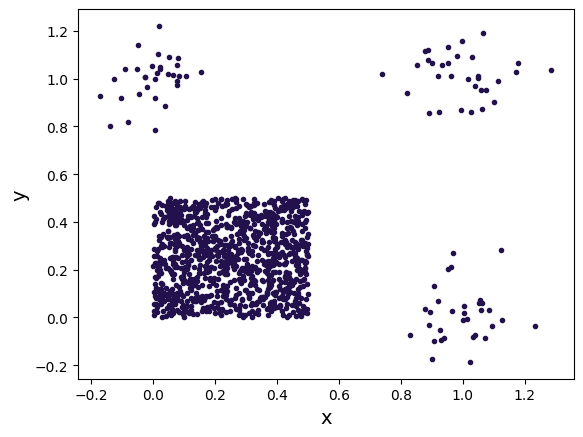

In [2]:
data_ex1, labels_ex1 = non_anomalous_outliers(
    # Number of regular objects
    inliers=1024,
    # Number of objects per each of three "outlier" classes
    outliers=32,
    # Classification of "outlier" classes
    regions=[Label.REGULAR, Label.REGULAR, Label.ANOMALY],
    seed=42
)

# Plot the data
plt.scatter(data_ex1[:,0], data_ex1[:,1], marker='.', color='#22114C')
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.show()

In [3]:
data_ex1

array([[ 0.38697802,  0.21943922],
       [ 0.42929896,  0.34868401],
       [ 0.04708867,  0.48781118],
       ...,
       [ 1.05489829,  0.07260984],
       [ 0.90689265, -0.09991449],
       [ 1.00368055,  0.01730071]], shape=(1120, 2))

In [4]:
# declare and fit an isolation forest
model_iso = IsolationForest(random_seed=0)
model_iso.fit(data_ex1)

# evaluate classification
scores_iso = model_iso.score_samples(data_ex1)

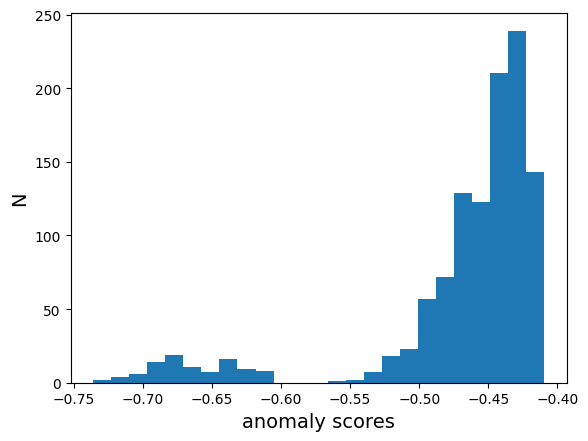

In [6]:
plt.figure()
plt.hist(scores_iso, bins=25)
plt.xlabel('anomaly scores', fontsize=14)
plt.ylabel('N', fontsize=14)
plt.show()

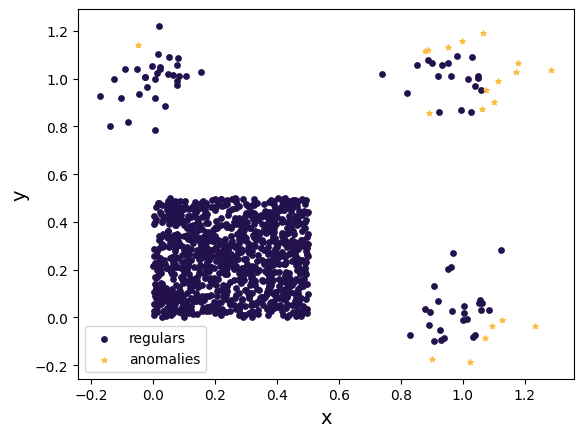

In [7]:
n = 20

indx = scores_iso.argsort()     # order objects according to their scores
anomalies = data_ex1[indx[:n]]  # separate anomalies
regulars = data_ex1[indx[n:]]   # separate regulars

plt.show()
plt.scatter(regulars[:,0], regulars[:,1], color='#22114C', marker='o',
            s=15, label='regulars')
plt.scatter(anomalies[:,0], anomalies[:,1], color='#FCBD43', marker='*',
            s=15, label='anomalies')
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend()
plt.show()

In [8]:
# metadata should include info that will help you decide
metadata_ex1 = np.array(
    [f'ID = {i}, {x = :.2f}, {y = :.2f}' for i, (x,y) in enumerate(data_ex1)]
)
metadata_ex1

array(['ID = 0, x = 0.39, y = 0.22', 'ID = 1, x = 0.43, y = 0.35',
       'ID = 2, x = 0.05, y = 0.49', ..., 'ID = 1117, x = 1.05, y = 0.07',
       'ID = 1118, x = 0.91, y = -0.10', 'ID = 1119, x = 1.00, y = 0.02'],
      shape=(1120,), dtype='<U30')

In [9]:
# declare the model parameters
model_ex1 = PineForest(
    # Use 1024 trees, a trade-off between speed and accuracy
    n_trees=1024,
    # Fix random seed for reproducibility
    random_seed=42,
)

session_ex1 = Session(
    # Data to use
    data=data_ex1,
    # Metadata to help an expert (you!)
    metadata=metadata_ex1,
    model=model_ex1,
    # Ask expert interactively
    decision_callback=prompt_decision_callback,
    # Stop after `n` objects
    on_decision_callbacks=TerminateAfter(3),
)

session_ex1.run()

Is ID = 1049, x = 1.29, y = 1.04 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):

  y


Is ID = 1028, x = 1.18, y = 1.07 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):

  n


Is ID = 1053, x = 1.17, y = 1.03 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):

  n


In [10]:
#  See targeted anomalies
session_ex1.known_anomalies

array([1049])

In [11]:
#  See targeted regulars
session_ex1.known_regulars

array([1028, 1053])

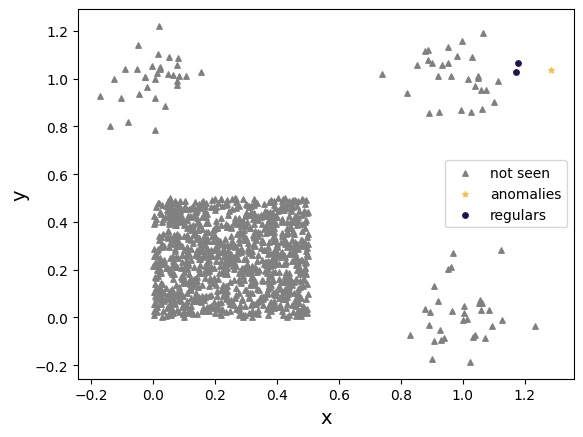

In [12]:
# Flag thins you did not see
flag_not_seen = ~np.isin(np.arange(data_ex1.shape[0]), list(session_ex1.known_labels))

plt.figure()
plt.scatter(*data_ex1[flag_not_seen].T,
            color='gray', marker='^', s=15, label='not seen')
plt.scatter(*data_ex1[session_ex1.known_anomalies].T,
            color='#FCBD43', marker='*', s=15 ,label='anomalies')
plt.scatter(*data_ex1[session_ex1.known_regulars].T,
            color='#22114C', marker='o', s=15, label='regulars')
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend()
plt.show()

In [13]:
n_anomalies = 32

data_ex2, labels_ex2 = non_anomalous_outliers(
    # Number of regular objects
    inliers=1024,
    #  Number of objects per each of three "outlier" classes
    outliers=n_anomalies,
    # Classification of "outlier" classes
    regions=[Label.R, Label.R, Label.A],
    seed=402,
)

labels_ex2

array([ 1,  1,  1, ..., -1, -1, -1], shape=(1120,))

In [14]:
# All objects in right bottom corner are anomalies
known_anomalies = np.where(
    (data_ex2[:, 0] > 0.6)    # Large x
    & (data_ex2[:, 1] < 0.5)  # Small y
)[0]

# No known regulars
known_regulars = np.array([], dtype=int)
# Or uncomment to actually add seven objects from the top right group
# known_regulars = np.where(
#     (data_ex2[:, 0] > 0.6)    # Large x
#     & (data_ex2[:, 1] > 0.6)  # Large y
# )[0][-7:]

known_idx = np.r_[known_anomalies, known_regulars]
known_data = data_ex2[known_idx]
known_labels = np.r_[
    np.full_like(known_anomalies, Label.ANOMALY, dtype=int),
    np.full_like(known_regulars, Label.REGULAR, dtype=int),
]

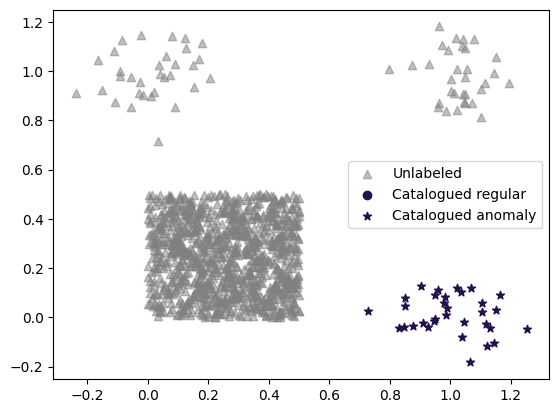

In [15]:
# Plot the data
unlabeled = ~np.isin(np.arange(data_ex2.shape[0]), known_idx)
plt.scatter(*data_ex2[unlabeled].T, marker='^', color='grey', alpha=0.5,
            label='Unlabeled')
plt.scatter(*data_ex2[known_regulars].T, marker='o', color='#22114C',
            label='Catalogued regular')
plt.scatter(*data_ex2[known_anomalies].T, marker='*', color='#22114C',
            label='Catalogued anomaly')
plt.legend()
plt.show()

In [16]:
model_ex2 = PineForest(random_seed=402)
model_ex2.fit_known(data_ex2, known_data=known_data, known_labels=known_labels)

In [17]:
scores_dex1_mex2 = model_ex2.score_samples(data_ex1)

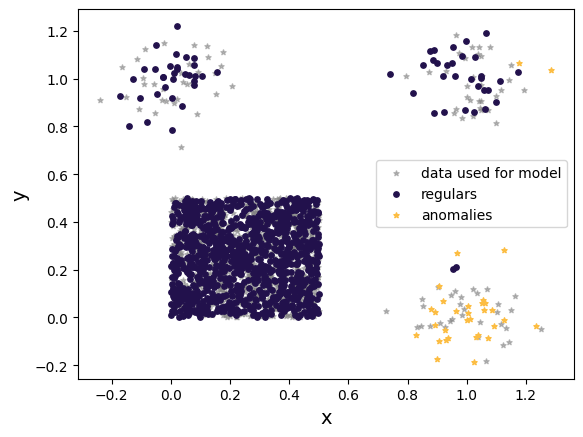

In [18]:
indx = scores_dex1_mex2.argsort()         # order objects according to their scores
anomalies = data_ex1[indx[:n_anomalies]]  # separate anomalies
regulars = data_ex1[indx[n_anomalies:]]   # separate regulars

plt.show()
plt.scatter(*data_ex2.T, color='gray', label='data used for model',
            alpha=0.5, s=15, marker="*")
plt.scatter(*regulars.T, color='#22114C', marker='o', s=15,
            label='regulars')
plt.scatter(*anomalies.T, color='#FCBD43', marker='*', s=15,
            label='anomalies')
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend()
plt.show()

In [24]:
from coniferest.datasets import ztf_m31

# import built-in data
data_ztf, metadata_ztf = ztf_m31()
print(data_ztf.shape)

(57546, 42)


In [25]:
data_ztf

array([[6.9950008e-01, 2.2794117e-01, 3.6764707e-02, ..., 2.0214492e-01,
        6.6418362e-01, 2.0516939e+01],
       [4.4299984e-01, 2.8888890e-01, 4.4444446e-02, ..., 1.6328827e-01,
        7.9298627e-01, 2.0698317e+01],
       [5.8949947e-01, 2.8000000e-01, 3.2000002e-02, ..., 1.9050223e-01,
        7.2875845e-01, 2.0749649e+01],
       ...,
       [7.3499680e-02, 2.7459016e-01, 4.9180329e-02, ..., 2.4325265e-02,
        7.9307187e-01, 1.7515738e+01],
       [4.3999672e-02, 3.1102362e-01, 7.4803151e-02, ..., 1.6327854e-02,
        7.9121703e-01, 1.5804447e+01],
       [1.9550037e-01, 2.2834645e-01, 5.5118110e-02, ..., 5.5768635e-02,
        7.1393239e-01, 1.8852880e+01]], shape=(57546, 42), dtype=float32)

In [26]:
metadata_ztf

array([695211400017839, 695211400043887, 695211400043454, ...,
       695211200027621, 695211200002462, 695211200070946],
      shape=(57546,), dtype=uint64)

In [27]:
model_ztf = PineForest(
    # Number of trees to use for predictions
    n_trees=256,
    # Number of new tree to grow for each decision
    n_spare_trees=768,
    # Fix random seed for reproducibility
    random_seed=0,
)

session_ztf = Session(
    data=data_ztf,
    metadata=metadata_ztf,
    model=model_ztf,
    # Prompt for a decision and open object's page on the SNAD Viewer
    decision_callback=viewer_decision_callback,
    on_decision_callbacks=[
        # Terminate session after 10 decisions
        TerminateAfter(3),
    ]
)
session_ztf.run()

Check https://ztf.snad.space/view/695211200075348 for details
Is 695211200075348 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):

  y


Check https://ztf.snad.space/view/695211400121607 for details
Is 695211400121607 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):

  y


Check https://ztf.snad.space/view/695211400027347 for details
Is 695211400027347 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):

  y
